In [2]:
import numpy as np 
import pandas as pd

In [3]:

# Create a sample dataset
data = {
 'Study_Hours': [2, 4, 6, 8, 10, 3, 5, 7, 9, 12],
 'Attendance': [60, 65, 70, 75, 80, 62, 68, 78, 85, 95],
 'Assignment_Score': [40, 50, 55, 65, 70, 45, 60, 72, 80, 90],
 'Exam_Score': [45, 50, 60, 65, 75, 48, 58, 70, 82, 95]
}
df = pd.DataFrame(data)
print("Original Dataset:")
print(df)
print("\nStatistical Summary:")
print(df.describe())

Original Dataset:
   Study_Hours  Attendance  Assignment_Score  Exam_Score
0            2          60                40          45
1            4          65                50          50
2            6          70                55          60
3            8          75                65          65
4           10          80                70          75
5            3          62                45          48
6            5          68                60          58
7            7          78                72          70
8            9          85                80          82
9           12          95                90          95

Statistical Summary:
       Study_Hours  Attendance  Assignment_Score  Exam_Score
count    10.000000   10.000000         10.000000   10.000000
mean      6.600000   73.800000         62.700000   64.800000
std       3.204164   10.992927         15.797679   15.991664
min       2.000000   60.000000         40.000000   45.000000
25%       4.250000   65.7500

In [4]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()
# Apply normalization
normalized_data = scaler.fit_transform(df)
# Convert into DataFrame
normalized_df = pd.DataFrame(normalized_data, columns=df.columns)
print("Normalized Dataset:")
print(normalized_df.round(2))
# Verify minimum and maximum
print("\nMinimum values:")
print(normalized_df.min())
print("\nMaximum values:")
print(normalized_df.max())


Normalized Dataset:
   Study_Hours  Attendance  Assignment_Score  Exam_Score
0          0.0        0.00              0.00        0.00
1          0.2        0.14              0.20        0.10
2          0.4        0.29              0.30        0.30
3          0.6        0.43              0.50        0.40
4          0.8        0.57              0.60        0.60
5          0.1        0.06              0.10        0.06
6          0.3        0.23              0.40        0.26
7          0.5        0.51              0.64        0.50
8          0.7        0.71              0.80        0.74
9          1.0        1.00              1.00        1.00

Minimum values:
Study_Hours         0.0
Attendance          0.0
Assignment_Score    0.0
Exam_Score          0.0
dtype: float64

Maximum values:
Study_Hours         1.0
Attendance          1.0
Assignment_Score    1.0
Exam_Score          1.0
dtype: float64


In [6]:
from sklearn.preprocessing import StandardScaler
# Initialize StandardScaler
scaler = StandardScaler()
# Apply standardization
standardized_data = scaler.fit_transform(df)
# Convert into DataFrame
standardized_df = pd.DataFrame(
 standardized_data,
 columns=df.columns
)
print("Standardized Dataset:")
print(standardized_df.round(2))
# Verify mean and standard deviation
print("\nMean of each feature:")
print(standardized_df.mean().round(2))
print("\nStandard deviation of each feature:")
print(standardized_df.std(ddof=0).round(2))

Standardized Dataset:
   Study_Hours  Attendance  Assignment_Score  Exam_Score
0        -1.51       -1.32             -1.51       -1.31
1        -0.86       -0.84             -0.85       -0.98
2        -0.20       -0.36             -0.51       -0.32
3         0.46        0.12              0.15        0.01
4         1.12        0.59              0.49        0.67
5        -1.18       -1.13             -1.18       -1.11
6        -0.53       -0.56             -0.18       -0.45
7         0.13        0.40              0.62        0.34
8         0.79        1.07              1.15        1.13
9         1.78        2.03              1.82        1.99

Mean of each feature:
Study_Hours         0.0
Attendance          0.0
Assignment_Score   -0.0
Exam_Score          0.0
dtype: float64

Standard deviation of each feature:
Study_Hours         1.0
Attendance          1.0
Assignment_Score    1.0
Exam_Score          1.0
dtype: float64


PCA Transformed Data:
    PC1   PC2
0 -2.83 -0.08
1 -1.76  0.00
2 -0.70  0.20
3  0.37  0.29
4  1.43  0.49
5 -2.30 -0.03
6 -0.86 -0.19
7  0.75 -0.32
8  2.08 -0.28
9  3.81 -0.08

Explained Variance Ratio:
[0.9802412  0.01467302]

Total Variance Retained:
0.9949142234776956


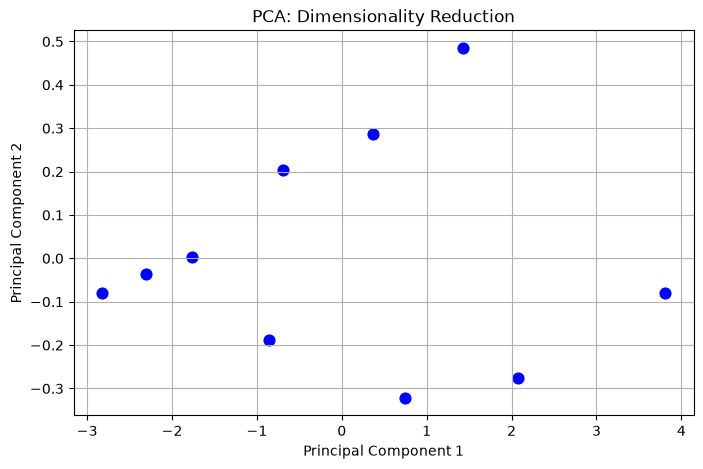

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Standardize the dataset
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
# Apply PCA to reduce 4 features to 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
# Create a DataFrame
pca_df = pd.DataFrame(
 pca_data,
 columns=['PC1', 'PC2']
)
print("PCA Transformed Data:")
print(pca_df.round(2))
# Explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("\nTotal Variance Retained:")
print(pca.explained_variance_ratio_.sum())
# Visualize PCA output
plt.figure(figsize=(8, 5))
plt.scatter(
 pca_df['PC1'],
 pca_df['PC2'],
 color='blue',
 s=60
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Dimensionality Reduction")
plt.grid(True)
plt.show()